In [7]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict, cross_validate

from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.base import clone




In [8]:
# Data
df = pd.read_parquet("../data/vrpp_df.parquet")
df.shape

(374642, 20)

In [9]:
TARGET_CLASS = "Delay_Status"

categorical_features = [
    "Local Port",
    "Trade",
    "Dry/Reefer",
    "Container Size",
    "Sailing Season"
]

numeric_features = [
    "Weight KGS",
    "Has Dangerous Cargo"   
]

FEATURES = categorical_features + numeric_features


# X / y
X = df[FEATURES].copy()
y = df[TARGET_CLASS].copy()

# convert binary flag to int
X["Has Dangerous Cargo"] = X["Has Dangerous Cargo"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y value counts:")
print(y.value_counts())

X shape: (374642, 7)
y shape: (374642,)
y value counts:
Delay_Status
Major Delay    226439
Minor Delay     73317
On Time         63298
Early           11588
Name: count, dtype: int64


In [10]:
# X / y
X = df[FEATURES].copy()
y = df[TARGET_CLASS].copy()


X["Has Dangerous Cargo"] = X["Has Dangerous Cargo"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nDtypes:")
print(X.dtypes)

X shape: (374642, 7)
y shape: (374642,)

Target distribution:
Delay_Status
Major Delay    226439
Minor Delay     73317
On Time         63298
Early           11588
Name: count, dtype: int64

Dtypes:
Local Port              object
Trade                   object
Dry/Reefer              object
Container Size           int64
Sailing Season          object
Weight KGS             float64
Has Dangerous Cargo      int64
dtype: object


In [11]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_prepared = preprocess.fit_transform(X_train)

print("Prepared train shape:", X_train_prepared.shape)
print("Prepared type:", type(X_train_prepared))

Prepared train shape: (299713, 381)
Prepared type: <class 'scipy.sparse._csr.csr_matrix'>


In [13]:
logreg = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    class_weight="balanced",
    solver="lbfgs",
    multi_class="auto"
)

logreg_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", logreg)
])

logreg_model.fit(X_train, y_train)

c:\Users\maxdo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred = logreg_model.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Logistic Regression — Macro F1:", macro_f1)
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Logistic Regression — Macro F1: 0.480298358641773

Classification report:
              precision    recall  f1-score   support

       Early       0.13      0.60      0.21      2318
 Major Delay       0.82      0.67      0.74     45288
 Minor Delay       0.37      0.37      0.37     14663
     On Time       0.62      0.59      0.60     12660

    accuracy                           0.60     74929
   macro avg       0.48      0.56      0.48     74929
weighted avg       0.67      0.60      0.63     74929



In [15]:
gb_clf = GradientBoostingClassifier(
    random_state=42
)

gb_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", gb_clf)
])

gb_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
y_pred = gb_model.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Gradient Boosting — Macro F1:", macro_f1)
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Gradient Boosting — Macro F1: 0.4972109110078653

Classification report:
              precision    recall  f1-score   support

       Early       0.47      0.22      0.30      2318
 Major Delay       0.72      0.94      0.82     45288
 Minor Delay       0.55      0.17      0.26     14663
     On Time       0.70      0.55      0.62     12660

    accuracy                           0.70     74929
   macro avg       0.61      0.47      0.50     74929
weighted avg       0.68      0.70      0.66     74929



In [17]:
voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(
            max_iter=2000,
            n_jobs=-1,
            class_weight="balanced"
        )),
        ("gb", GradientBoostingClassifier(
            random_state=42
        ))
    ],
    voting="soft"   
)

voting_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", voting_clf)
])


voting_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
y_pred = voting_model.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Voting (LR + GB) — Macro F1:", macro_f1)
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Voting (LR + GB) — Macro F1: 0.5102272927494806

Classification report:
              precision    recall  f1-score   support

       Early       0.25      0.34      0.29      2318
 Major Delay       0.76      0.86      0.81     45288
 Minor Delay       0.45      0.26      0.33     14663
     On Time       0.64      0.59      0.61     12660

    accuracy                           0.68     74929
   macro avg       0.52      0.51      0.51     74929
weighted avg       0.66      0.68      0.67     74929



In [19]:
base_estimators = [
    (
        "lr",
        LogisticRegression(
            max_iter=2000,
            n_jobs=-1,
            class_weight="balanced",
            solver="lbfgs"
        )
    ),
    (
        "gb",
        GradientBoostingClassifier(
            random_state=42
        )
    )
]


In [20]:
meta_estimator = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    solver="lbfgs"
)

In [21]:
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

In [22]:
stacking_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", stacking_clf)
])

stacking_model.fit(X_train, y_train)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
y_pred = stacking_model.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Stacking (LR + GB) — Macro F1:", macro_f1)
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Stacking (LR + GB) — Macro F1: 0.5205765502089893

Classification report:
              precision    recall  f1-score   support

       Early       0.47      0.22      0.30      2318
 Major Delay       0.75      0.92      0.82     45288
 Minor Delay       0.50      0.25      0.33     14663
     On Time       0.68      0.58      0.62     12660

    accuracy                           0.71     74929
   macro avg       0.60      0.49      0.52     74929
weighted avg       0.68      0.71      0.68     74929



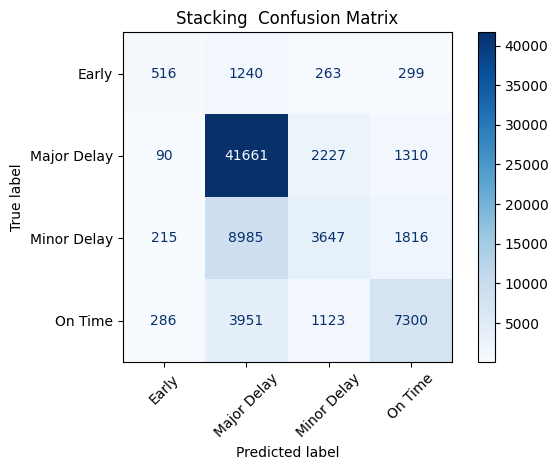

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    stacking_model.predict(X_test),
    xticks_rotation=45,
    cmap="Blues"
)
plt.title("Stacking  Confusion Matrix")
plt.tight_layout()
plt.show()


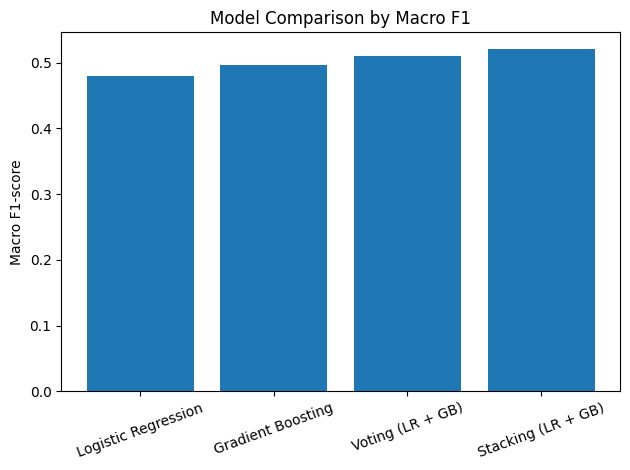

In [25]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting",
        "Voting (LR + GB)",
        "Stacking (LR + GB)"
    ],
    "Macro F1": [
        0.480,
        0.497,
        0.510,
        0.520
    ]
})

plt.figure()
plt.bar(results_df["Model"], results_df["Macro F1"])
plt.xticks(rotation=20)
plt.ylabel("Macro F1-score")
plt.title("Model Comparison by Macro F1")
plt.tight_layout()
plt.show()

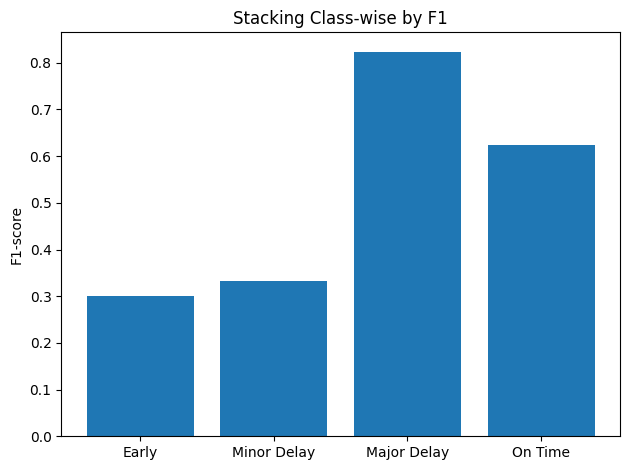

In [26]:
report = classification_report(
    y_test,
    stacking_model.predict(X_test),
    output_dict=True
)

f1_df = (
    pd.DataFrame(report)
    .T
    .loc[["Early", "Minor Delay", "Major Delay", "On Time"], ["f1-score"]]
)

plt.figure()
plt.bar(f1_df.index, f1_df["f1-score"])
plt.ylabel("F1-score")
plt.title("Stacking Class-wise by F1")
plt.tight_layout()
plt.show()

In [27]:
class_order = stacking_model.named_steps["clf"].classes_
print("Class order:", class_order)

Class order: ['Early' 'Major Delay' 'Minor Delay' 'On Time']


In [28]:
proba = stacking_model.predict_proba(X)

print("Proba shape:", proba.shape)

Proba shape: (374642, 4)


In [29]:
proba_df = pd.DataFrame(
    proba,
    columns=class_order,
    index=X.index
)

proba_df.head()

,Early,Major Delay,Minor Delay,On Time
0,0.028802,0.286584,0.564595,0.120019
1,0.011086,0.832216,0.102631,0.054068
2,0.006557,0.883542,0.084182,0.025719
3,0.005859,0.895065,0.075611,0.023465
4,0.005862,0.895165,0.075527,0.023446


In [30]:
rl_state = pd.DataFrame(index=X.index)

rl_state["p_major"] = proba_df["Major Delay"]
rl_state["p_minor"] = proba_df["Minor Delay"]

rl_state.head()

,p_major,p_minor
0,0.286584,0.564595
1,0.832216,0.102631
2,0.883542,0.084182
3,0.895065,0.075611
4,0.895165,0.075527


In [31]:
season_dummies = pd.get_dummies(
    df["Sailing Season"],
    prefix="season"
)

season_dummies.head()

,season_Autumn,season_Spring,season_Summer,season_Winter
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True


In [32]:
rl_state = rl_state.join(season_dummies)

In [33]:
weight = df["Weight KGS"].astype(float)

weight_norm = (weight - weight.min()) / (weight.max() - weight.min())

rl_state["weight_norm"] = weight_norm

In [34]:
rl_state["delay_hours"] = df["Delay_Hours"].astype(float)

In [35]:
print(rl_state.shape)
rl_state.head()

(374642, 8)


,p_major,p_minor,season_Autumn,season_Spring,season_Summer,season_Winter,weight_norm,delay_hours
0,0.286584,0.564595,False,False,False,True,0.009321,96.0
1,0.832216,0.102631,False,False,False,True,0.018350,96.0
2,0.883542,0.084182,False,False,False,True,0.022340,96.0
3,0.895065,0.075611,False,False,False,True,0.021095,96.0
4,0.895165,0.075527,False,False,False,True,0.005579,96.0


In [36]:
season_cols = [c for c in rl_state.columns if c.startswith("season_")]
rl_state[season_cols] = rl_state[season_cols].astype(int)


In [37]:
rl_state[season_cols].dtypes


season_Autumn    int64
season_Spring    int64
season_Summer    int64
season_Winter    int64
dtype: object

In [38]:
rl_state = rl_state[
    [
        "p_major",
        "p_minor",
        "season_Winter",
        "season_Spring",
        "season_Summer",
        "season_Autumn",
        "weight_norm",
        "delay_hours",
    ]
]

In [39]:
rl_state.head()


,p_major,p_minor,season_Winter,season_Spring,season_Summer,season_Autumn,weight_norm,delay_hours
0,0.286584,0.564595,1,0,0,0,0.009321,96.0
1,0.832216,0.102631,1,0,0,0,0.018350,96.0
2,0.883542,0.084182,1,0,0,0,0.022340,96.0
3,0.895065,0.075611,1,0,0,0,0.021095,96.0
4,0.895165,0.075527,1,0,0,0,0.005579,96.0


In [40]:
season_cols = [
    "season_Winter",
    "season_Spring",
    "season_Summer",
    "season_Autumn",
]

rl_state[season_cols].sum().sort_values(ascending=False)


season_Spring    130444
season_Summer    126351
season_Winter     77034
season_Autumn     40813
dtype: int64

In [41]:
rl_state[season_cols].mean().sort_values(ascending=False)


season_Spring    0.348183
season_Summer    0.337258
season_Winter    0.205620
season_Autumn    0.108939
dtype: float64

In [42]:
rl_state.to_parquet("../data/rl_state_base.parquet", index=False)


In [43]:
p99_delay = df["Delay_Hours"].quantile(0.99)
p99_delay


np.float64(696.0)

In [44]:
import json
from pathlib import Path

reward_stats = {
    "p99_delay_hours": float(p99_delay)
}

reward_stats_path = Path("../data/reward_stats.json")

with open(reward_stats_path, "w") as f:
    json.dump(reward_stats, f, indent=2)

print("Saved to:", reward_stats_path)

Saved to: ..\data\reward_stats.json


In [45]:
rl_state_clean = rl_state.dropna(subset=["delay_hours"]).reset_index(drop=True)

print("Before:", rl_state.shape)
print("After :", rl_state_clean.shape)

Before: (374642, 8)
After : (363054, 8)


In [46]:
rl_state_clean.to_parquet("../data/rl_state_base.parquet", index=False)


In [47]:
pd.read_parquet("../data/rl_state_base.parquet").isna().sum()

p_major          0
p_minor          0
season_Winter    0
season_Spring    0
season_Summer    0
season_Autumn    0
weight_norm      0
delay_hours      0
dtype: int64

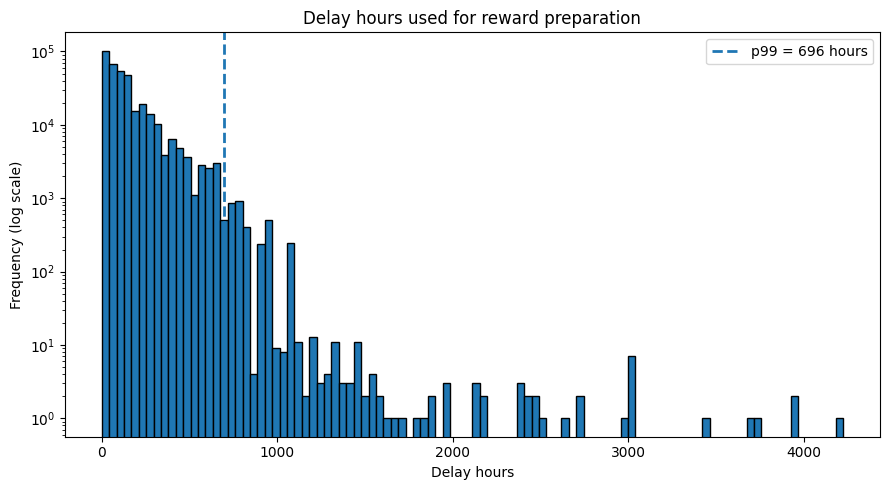

In [48]:
delay_plot = rl_state_clean["delay_hours"].astype(float)

plt.figure(figsize=(9, 5))
plt.hist(delay_plot, bins=100, log=True, edgecolor="black")
plt.axvline(p99_delay, linestyle="--", linewidth=2, label=f"p99 = {p99_delay:.0f} hours")

plt.xlabel("Delay hours")
plt.ylabel("Frequency (log scale)")
plt.title("Delay hours used for reward preparation")
plt.legend()
plt.tight_layout()
plt.show()